<a href="https://colab.research.google.com/github/vstimpson/scientific-computing-projects/blob/main/Valentina_Stimpson_VACS2_Trinity_College_Session5_IA_SciComp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NST IA Scientific Computing Session 5

# Advanced and 3D plotting

<hr style="border:2px solid black"> </hr>


## Section 2 for submission - Producing 3D plots for waves

  This is the part you need to do for assessment.
  Start a new jupyter notebook, and do there what requested below.
  
  We will explore 3D graphics capabilities in the context of
waves.
  A  wave in one dimension is a function of position $x$ and time $t$ that is solution
of the wave equation,
\begin{equation*}
\frac{\partial^2 \psi}{\partial x^2} = \frac{1}{c^2} \frac{\partial^2 \psi}{\partial t^2} \, ,
\end{equation*}
being $c$ the wave velocity (e.g. for sound waves in air $c=340$ m/s).
  General solutions of this equations are functions $\psi=f(x-ct)$ and
$\psi=f(x+ct)$, and linear combinations thereof.
  The former represents waves travelling to the right, the latter to the left.
  
  Let us consider here a wave of the form
\begin{equation}
\psi_b(x,t) = \frac{A}{2} \left ( \frac{\sin [ k (x-ct) ]}{k(x-ct)} + \frac{\sin [ k (x+ct) ]}{k(x+ct)} \right )
\end{equation}
where $A$ is the amplitude of the wave and $k$ a constant
of wave-number dimensions.
  It represents a oscillating pulse that spreads and separates into
two pulses, travelling in opposite directions.
  We will compare it with the same initial pulse (at $t=0$)
but travelling only to the right, as
\begin{equation}
\psi_r(x,t) = A \frac{\sin [ k (x-ct) ]}{k(x-ct)} \, .
\end{equation}
  At $t=0$ they both have the same shape.
\begin{equation}
\psi_b(x,0)=\psi_r(x,0) = A \frac{\sin (kx)}{kx} \, .
\end{equation}

We will consider here $c=1$, $A=1$ and $k=2\pi$.

In [ ]:
import numpy as np
def psi_b(x,t):
    # np.sinc(x) is defined as sin(pi*x)/(pi*x)
    # Our expression is sin(2*pi*arg)/(2*pi*arg), so we use np.sinc(2*arg)
    arg_minus = (x-t)
    arg_plus = (x+t)
    return 0.5 * (np.sinc(2 * arg_minus) + np.sinc(2 * arg_plus))

def psi_r(x,t):
  arg_minus = (x-t)
  return np.sinc(2 * arg_minus)

### (a) Regular 2D plots (two)

- Produce a figure displaying the shape of $\psi_r$ as a function of $x$,
  at times $t=0$, $t=1$, and $t=-1$.
  - Distinguish the curves for different times with different line styles or colours,
    and with a text label at covenient locations besides the curves.
  - Do it for $x$ in the range $x \in [-3.5, 3.5]$.
  - Tailor the tick positions and labels, as well as a title, with fonts of adequate size.
  
- Produce second figure as above, now for $\psi_b$, for $t=0$, $t=0.6$, and $t=1.8$,
  but using a legend instead of text labels.



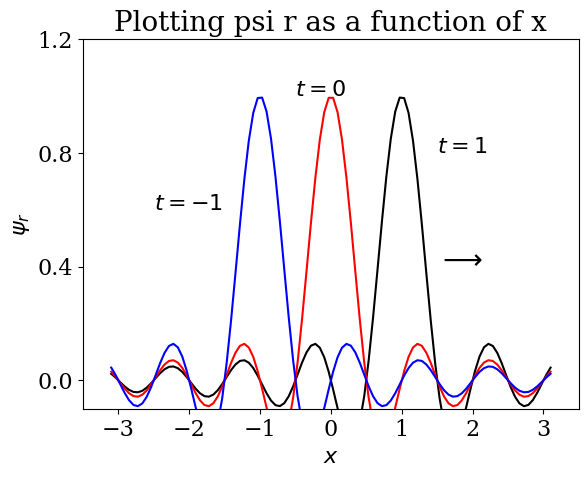

In [ ]:
import matplotlib.pyplot as plt
# Set font for labels in coming figures
font16 = {'family': 'serif',
          'color':  'black',
          'weight': 'normal',
          'size': 16,
          }

# Set font for labels in coming figures
font20 = {'family': 'serif',
          'color':  'black',
          'weight': 'normal',
          'size': 20,
          }
plt.title('Plotting psi r as a function of x', fontdict=font20)
plt.xlim(-3.5,3.5)
plt.ylim(-0.1,1.1)
plt.xticks(np.arange(-3, 4, step=1),fontsize=16,fontfamily='serif') # style={'normal', 'italic', 'oblique'}
plt.yticks(np.arange(0., 1.4, step=0.4),fontsize=16,fontfamily='serif')
plt.xlabel('$x$', fontdict=font16)
plt.ylabel(r'$\psi_r$', fontdict=font16)

plt.text(-0.5, 1.0, r'$t= 0$', fontdict=font16)
plt.text( 1.5, 0.8, r'$t= 1$', fontdict=font16)
plt.text(-2.5, 0.6, r'$t= -1$', fontdict=font16)
plt.text( 1.5, 0.4, r'$\longrightarrow$', fontdict=font20) # This is added to indicate displacement

x = np.linspace(-3.1,3.1,100)

plt.plot(x,psi_r(x,1), color='k')
plt.plot(x,psi_r(x,0), color='r')
plt.plot(x,psi_r(x,-1), color='b')

plt.show()

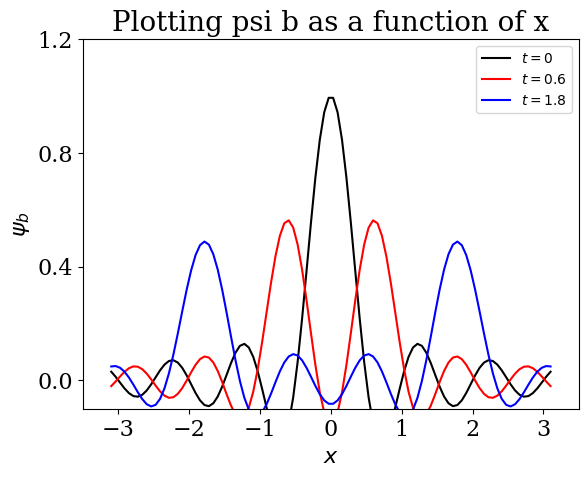

In [ ]:
import matplotlib.pyplot as plt
# Set font for labels in coming figures
font16 = {'family': 'serif',
          'color':  'black',
          'weight': 'normal',
          'size': 16,
          }

# Set font for labels in coming figures
font20 = {'family': 'serif',
          'color':  'black',
          'weight': 'normal',
          'size': 20,
          }
plt.title('Plotting psi b as a function of x', fontdict=font20)
plt.xlim(-3.5,3.5)
plt.ylim(-0.1,1.1)
plt.xticks(np.arange(-3, 4, step=1),fontsize=16,fontfamily='serif') # style={'normal', 'italic', 'oblique'}
plt.yticks(np.arange(0., 1.4, step=0.4),fontsize=16,fontfamily='serif')
plt.xlabel('$x$', fontdict=font16)
plt.ylabel(r'$\psi_b$', fontdict=font16)

x = np.linspace(-3.1,3.1,100)

plt.plot(x,psi_b(x,0), color='k')
plt.plot(x,psi_b(x,0.6), color='r')
plt.plot(x,psi_b(x,1.8), color='b')

plt.legend(['$t=0$', '$t=0.6$', '$t=1.8$'])

plt.show()

### (b) Contour plots (three)

- Produce a contour plot figure for $\psi_r(x,t)$ using `contourf` (filled).
  - Use the $t$ coordinate as second (as $y$, it will appear vertically in the plot)
  - Use the ranges $x\in[-1.5,1.5]$, and $t\in[-0.5,2.5]$.
  - Use a colourmap that allows perceiving the transmitted information.
  - Control ticks, labels, title and fonts.
- Produce a second figure, repeating the former for $\psi_b(x,t)$.
- Produce a third figure, again for $\psi_b(x,t)$, with `contour` instead of `contourf`.
- Save the last figure as vector graph in a `pdf` file.

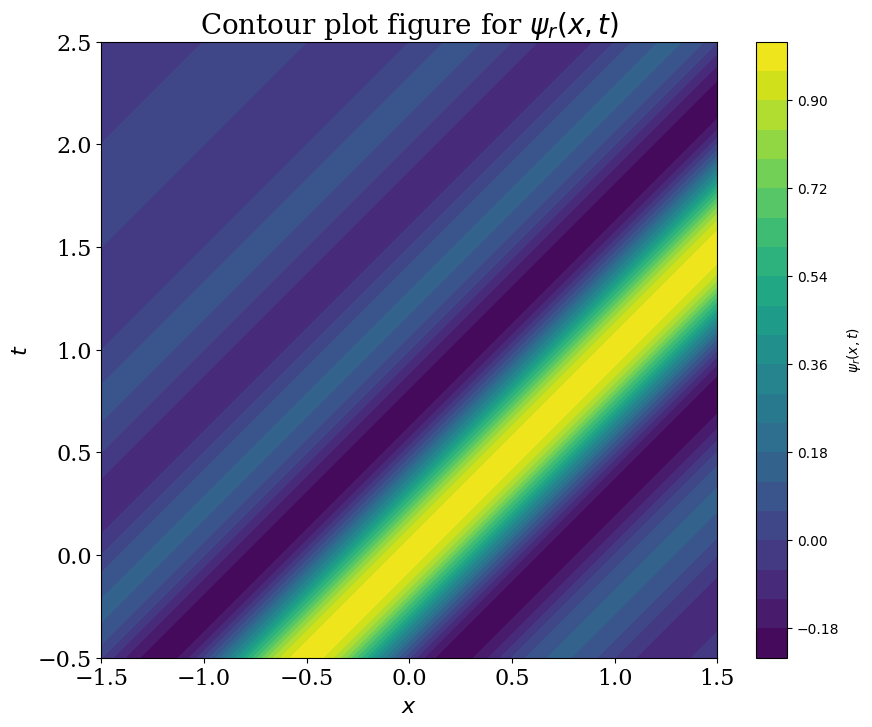

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the ranges for x and t
x_range = np.linspace(-1.5, 1.5, 1000)
t_range = np.linspace(-0.5, 2.5, 1000)

# Create a meshgrid for x and t
X, T = np.meshgrid(x_range, t_range)

# Calculate psi_r(x,t) for the meshgrid
z_r = psi_r(X, T)

plt.figure(figsize=(10, 8))
plt.axes().set_aspect('equal')
plt.title(r'Contour plot figure for $\psi_r(x,t)$', fontdict=font20)
plt.xlabel(r'$x$', fontdict=font16)
plt.ylabel(r'$t$', fontdict=font16)
plt.xticks(np.arange(-1.5, 1.6, step=0.5), fontsize=16, fontfamily='serif')
plt.yticks(np.arange(-0.5, 2.6, step=0.5), fontsize=16, fontfamily='serif')

# Using contourf as requested for psi_r
plt.contourf(X, T, z_r, levels=20, cmap='viridis') # Using 'viridis' colormap
plt.colorbar(label=r'$\psi_r(x,t)$')
plt.show()

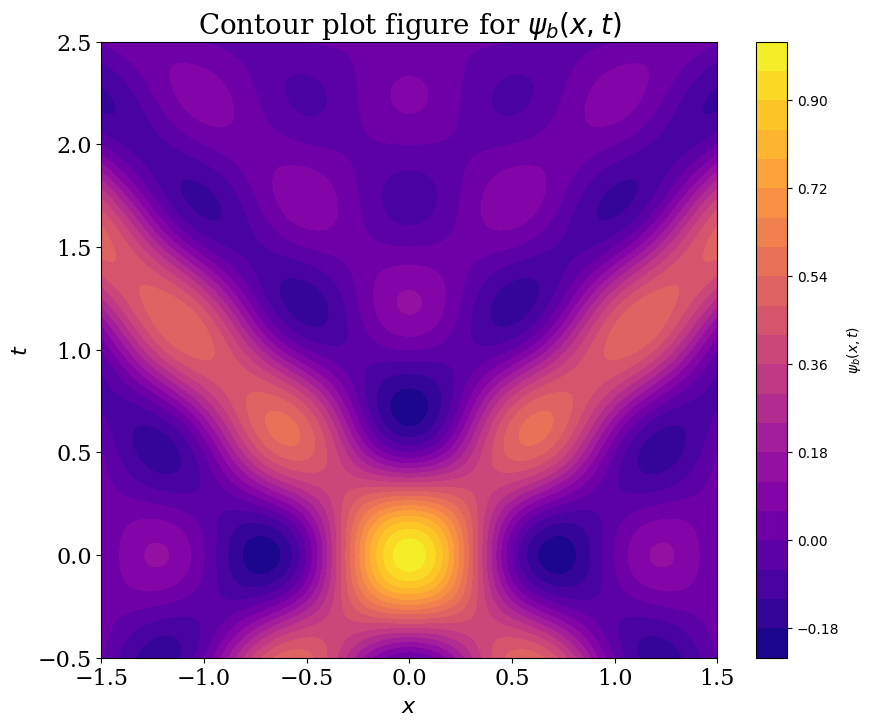

In [ ]:
# Calculate psi_b(x,t) for the meshgrid
z_b = psi_b(X, T)

plt.figure(figsize=(10, 8))
plt.axes().set_aspect('equal')
plt.title(r'Contour plot figure for $\psi_b(x,t)$', fontdict=font20)
plt.xlabel(r'$x$', fontdict=font16)
plt.ylabel(r'$t$', fontdict=font16)
plt.xticks(np.arange(-1.5, 1.6, step=0.5), fontsize=16, fontfamily='serif')
plt.yticks(np.arange(-0.5, 2.6, step=0.5), fontsize=16, fontfamily='serif')
plt.contourf(X, T, z_b, levels=20, cmap='plasma') # Using 'plasma' colormap
plt.colorbar(label=r'$\psi_b(x,t)$')
plt.show()

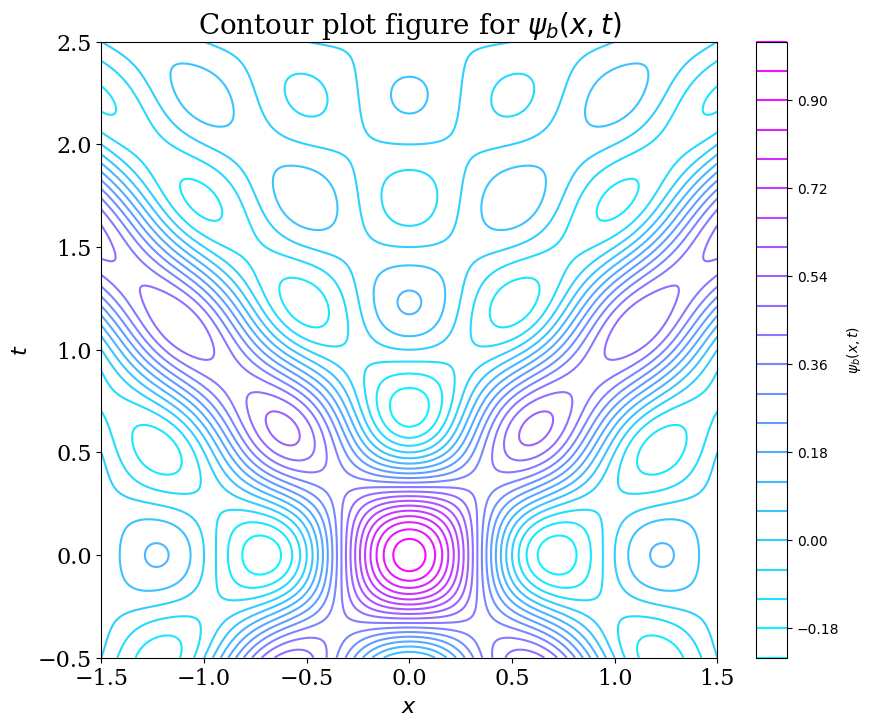

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 8))
plt.axes().set_aspect('equal')
plt.title(r'Contour plot figure for $\psi_b(x,t)$', fontdict=font20)
plt.xlabel(r'$x$', fontdict=font16)
plt.ylabel(r'$t$', fontdict=font16)
plt.xticks(np.arange(-1.5, 1.6, step=0.5), fontsize=16, fontfamily='serif')
plt.yticks(np.arange(-0.5, 2.6, step=0.5), fontsize=16, fontfamily='serif')
plt.contour(X, T, z_b, levels=20, cmap='cool') # Using 'cool' colormap as in original code
plt.colorbar(label=r'$\psi_b(x,t)$')

plt.savefig('contours.png',format='png', dpi=300) # bitmap graph
plt.savefig('contours.pdf',format='pdf')          # vector graph
plt.show()

plt.savefig('plt.eps', format='eps')

### (c) Surface plots (two)

- Represent $\psi_b(x,t)$ as a surface in a 3D plot in the same $(x,t)$ domain
  as the countour plots above.
  - Choose a viewpoint that allows good perception of the shape of $\psi_b$.
- Produce a second 3D figure of the same function using now a wireframe representation.
  - For clarity in this last one, reduce the $(x,t)$ domain to $x\in[-1,1]$ and $t\in[-0.5,1.5]$.
  - Also for clarity, redefine the view point (you may need to see it from higher up).

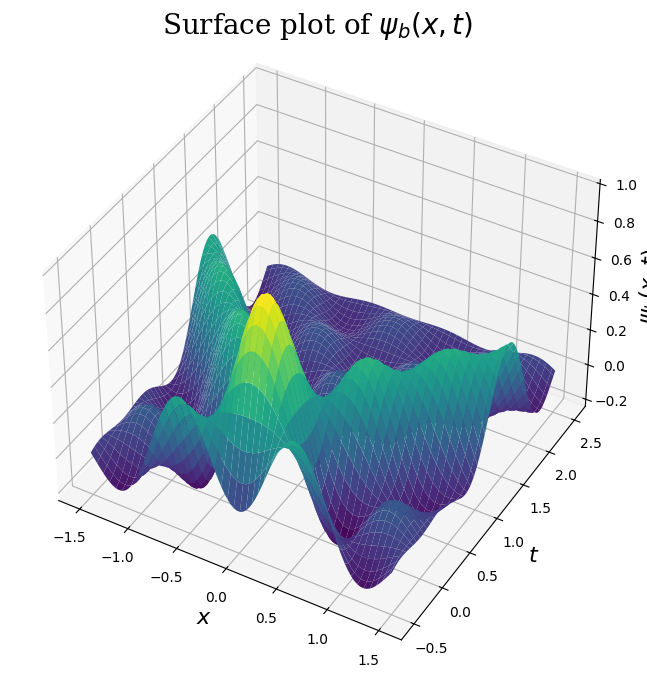

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# First 3D plot (surface for psi_b)
x_range_3d_1 = np.linspace(-1.5, 1.5, 100)
t_range_3d_1 = np.linspace(-0.5, 2.5, 100)
X_3d_1, T_3d_1 = np.meshgrid(x_range_3d_1, t_range_3d_1)
Z_3d_1 = psi_b(X_3d_1, T_3d_1)

fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot_surface(X_3d_1, T_3d_1, Z_3d_1, cmap='viridis')
ax1.set_xlabel(r'$x$', fontdict=font16)
ax1.set_ylabel(r'$t$', fontdict=font16)
ax1.set_zlabel(r'$\psi_b(x,t)$', fontdict=font16)
ax1.set_title(r'Surface plot of $\psi_b(x,t)$', fontdict=font20)
ax1.view_init(elev=40, azim=-60)
plt.show()

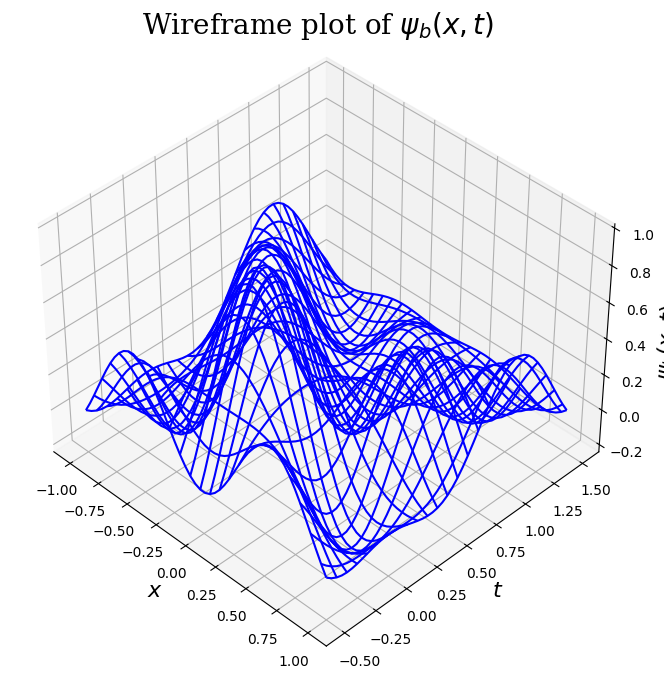

In [ ]:
x_range_3d_2 = np.linspace(-1, 1, 50)
t_range_3d_2 = np.linspace(-0.5, 1.5, 50)
X_3d_2, T_3d_2 = np.meshgrid(x_range_3d_2, t_range_3d_2)
Z_3d_2 = psi_b(X_3d_2, T_3d_2)

fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.plot_wireframe(X_3d_2, T_3d_2, Z_3d_2, rstride=2, cstride=2, color='blue')
ax2.set_xlabel(r'$x$', fontdict=font16)
ax2.set_ylabel(r'$t$', fontdict=font16)
ax2.set_zlabel(r'$\psi_b(x,t)$', fontdict=font16)
ax2.set_title(r'Wireframe plot of $\psi_b(x,t)$', fontdict=font20)
ax2.view_init(elev=40, azim=-45) # Higher viewpoint
plt.show()